In [1]:
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

data = {
    "Patient_ID": ["P001", "P002", "P003", "P004", "P005"],
    "Name": ["Amit", "Riya", "Rahul", "Pooja", "Arjun"],
    "Age": [45, 30, 60, 25, 50],
    "Gender": ["M", "F", "M", "F", "M"],
    "Disease": ["Diabetes", "Fever", "Heart Disease", "Flu", "Diabetes"],
    "Admission_Type": ["Emergency", "OPD", "Emergency", "OPD", "Emergency"],
    "Doctor": ["Dr Sharma", "Dr Verma", "Dr Singh", "Dr Gupta", "Dr Sharma"],
    "Days_Admitted": [5, 2, 10, 1, 6],
    "Hospital_Bill": [20000, 5000, 50000, 3000, 22000]
}

df = pd.DataFrame(data)

df

,Patient_ID,Name,Age,Gender,Disease,Admission_Type,Doctor,Days_Admitted,Hospital_Bill
0,P001,Amit,45,M,Diabetes,Emergency,Dr Sharma,5,20000
1,P002,Riya,30,F,Fever,OPD,Dr Verma,2,5000
2,P003,Rahul,60,M,Heart Disease,Emergency,Dr Singh,10,50000
3,P004,Pooja,25,F,Flu,OPD,Dr Gupta,1,3000
4,P005,Arjun,50,M,Diabetes,Emergency,Dr Sharma,6,22000


In [3]:
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      5 non-null      object
 1   Name            5 non-null      object
 2   Age             5 non-null      int64 
 3   Gender          5 non-null      object
 4   Disease         5 non-null      object
 5   Admission_Type  5 non-null      object
 6   Doctor          5 non-null      object
 7   Days_Admitted   5 non-null      int64 
 8   Hospital_Bill   5 non-null      int64 
dtypes: int64(3), object(6)
memory usage: 492.0+ bytes


In [4]:
df.describe() 

,Age,Days_Admitted,Hospital_Bill
count,5.00000,5.000000,5.000000
mean,42.00000,4.800000,20000.000000
std,14.40486,3.563706,18828.170384
min,25.00000,1.000000,3000.000000
25%,30.00000,2.000000,5000.000000
50%,45.00000,5.000000,20000.000000
75%,50.00000,6.000000,22000.000000
max,60.00000,10.000000,50000.000000


In [5]:
df.isnull().sum()

Patient_ID        0
Name              0
Age               0
Gender            0
Disease           0
Admission_Type    0
Doctor            0
Days_Admitted     0
Hospital_Bill     0
dtype: int64

In [6]:
df["Disease"].value_counts()
df["Gender"].value_counts()

Gender
M    3
F    2
Name: count, dtype: int64

In [7]:
df[df["Disease"] == "Diabetes"]

,Patient_ID,Name,Age,Gender,Disease,Admission_Type,Doctor,Days_Admitted,Hospital_Bill
0,P001,Amit,45,M,Diabetes,Emergency,Dr Sharma,5,20000
4,P005,Arjun,50,M,Diabetes,Emergency,Dr Sharma,6,22000


In [8]:
df.groupby("Disease")["Hospital_Bill"].mean() #Har disease ka average bill

Disease
Diabetes         21000.0
Fever             5000.0
Flu               3000.0
Heart Disease    50000.0
Name: Hospital_Bill, dtype: float64

In [9]:
df.sort_values(by="Hospital_Bill", ascending=False)

,Patient_ID,Name,Age,Gender,Disease,Admission_Type,Doctor,Days_Admitted,Hospital_Bill
2,P003,Rahul,60,M,Heart Disease,Emergency,Dr Singh,10,50000
4,P005,Arjun,50,M,Diabetes,Emergency,Dr Sharma,6,22000
0,P001,Amit,45,M,Diabetes,Emergency,Dr Sharma,5,20000
1,P002,Riya,30,F,Fever,OPD,Dr Verma,2,5000
3,P004,Pooja,25,F,Flu,OPD,Dr Gupta,1,3000


In [10]:
df["Bill_per_day"] = df["Hospital_Bill"] / df["Days_Admitted"]

In [11]:
df

,Patient_ID,Name,Age,Gender,Disease,Admission_Type,Doctor,Days_Admitted,Hospital_Bill,Bill_per_day
0,P001,Amit,45,M,Diabetes,Emergency,Dr Sharma,5,20000,4000.000000
1,P002,Riya,30,F,Fever,OPD,Dr Verma,2,5000,2500.000000
2,P003,Rahul,60,M,Heart Disease,Emergency,Dr Singh,10,50000,5000.000000
3,P004,Pooja,25,F,Flu,OPD,Dr Gupta,1,3000,3000.000000
4,P005,Arjun,50,M,Diabetes,Emergency,Dr Sharma,6,22000,3666.666667


**Disease Count**

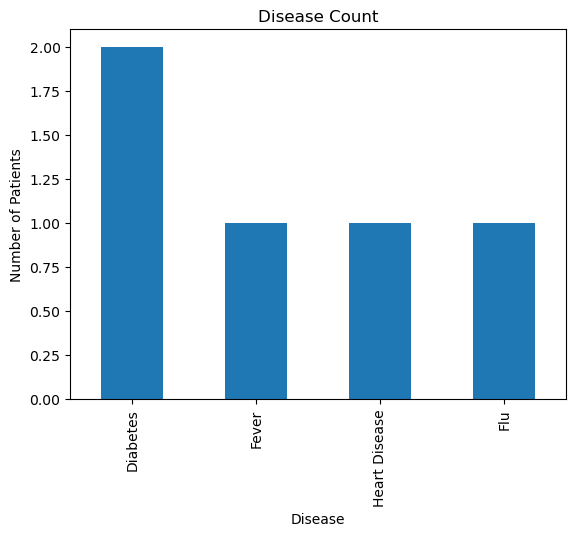

In [12]:
df["Disease"].value_counts().plot(kind="bar")
plt.title("Disease Count")
plt.xlabel("Disease")
plt.ylabel("Number of Patients")
plt.show()

**Gender Distribution**

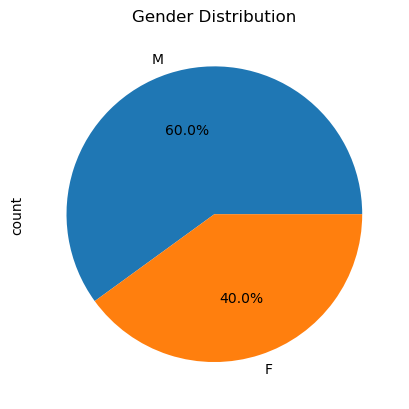

In [14]:
df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.show()


**Hospital Bill**

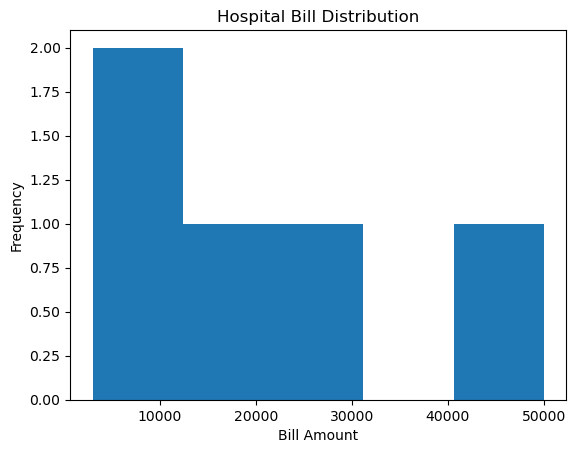

In [15]:
plt.hist(df["Hospital_Bill"], bins=5)
plt.title("Hospital Bill Distribution")
plt.xlabel("Bill Amount")
plt.ylabel("Frequency")
plt.show()

**Heatmap**

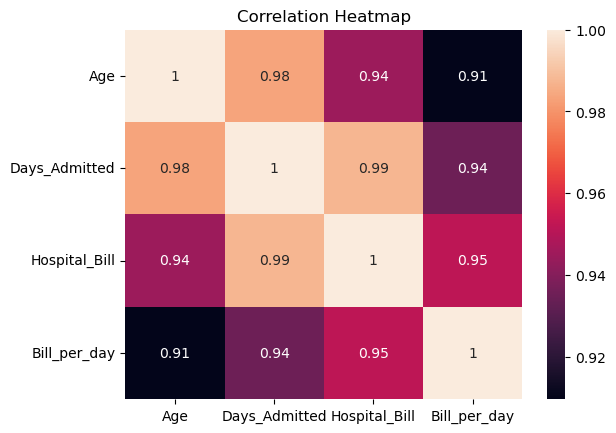

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sirf numeric columns ka correlation
corr = df.corr(numeric_only=True)

# Heatmap
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()